# ANÁLISIS DE MÚSICA Y SALUD MENTAL
## Minería de Datos - Evaluación 2

**Integrantes:** Alejandra Guzman - Macarena Lobos  
**Sección:** 002D  
**Objetivo:** Predecir el efecto de la música en la salud mental

---
## COMPRENSIÓN DEL NEGOCIO

### Tema del Proyecto
**"Análisis de la relación entre hábitos de consumo de música y problemas de salud mental"**

### Descripción
Analizamos datos de 300+ usuarios que respondieron una encuesta sobre:
- Hábitos de escucha de música
- Niveles de ansiedad, depresión, insomnio y OCD
- Cómo la música afecta su salud mental

### Objetivos
1. **Segmentación:** Identificar grupos de oyentes similares
2. **Predicción:** ¿La música mejora, empeora o no tiene efecto?
3. **Insights:** Qué variables son más importantes

### Pregunta de Negocio
¿Qué características predicen mejor si la música mejora la salud mental de una persona?

---
## 2️⃣ IMPORTACIÓN DE LIBRERÍAS

In [6]:
# 📦 LIBRERÍAS DE DATOS
import pandas as pd
import numpy as np

# 📊 LIBRERÍAS DE VISUALIZACIÓN
import matplotlib.pyplot as plt
import seaborn as sns

# 🔧 LIBRERÍAS DE PREPROCESAMIENTO
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

# 📈 LIBRERÍAS DE MODELADO
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# 📊 MÉTRICAS
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# 🎯 CLUSTERING
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# 📐 UTILIDADES
from scipy.stats import entropy
import warnings
warnings.filterwarnings('ignore')

# ⚙️ CONFIGURAR
plt.style.use('default')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


---
## 3️⃣ CARGA E INTEGRACIÓN DEL DATASET

In [7]:
# Cargar datos
df = pd.read_csv("/content/musica_y_salud_mental.csv")

df.head()


,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,BPM,Frequency [Classical],Frequency [Country],Frequency [EDM],Frequency [Folk],Frequency [Gospel],Frequency [Hip hop],Frequency [Jazz],Frequency [K pop],Frequency [Latin],Frequency [Lofi],Frequency [Metal],Frequency [Pop],Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,156.0,Rarely,Never,Rarely,Never,Never,Sometimes,Never,Very frequently,Very frequently,Rarely,Never,Very frequently,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,119.0,Sometimes,Never,Never,Rarely,Sometimes,Rarely,Very frequently,Rarely,Sometimes,Rarely,Never,Sometimes,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,132.0,Never,Never,Very frequently,Never,Never,Rarely,Rarely,Very frequently,Never,Sometimes,Sometimes,Rarely,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,84.0,Sometimes,Never,Never,Rarely,Sometimes,Never,Very frequently,Sometimes,Very frequently,Sometimes,Never,Sometimes,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,107.0,Never,Never,Rarely,Never,Rarely,Very frequently,Never,Very frequently,Sometimes,Sometimes,Never,Sometimes,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


---
## 4️⃣ COMPRENSIÓN DE LOS DATOS

In [8]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     736 non-null    object 
 1   Age                           735 non-null    float64
 2   Primary streaming service     735 non-null    object 
 3   Hours per day                 736 non-null    float64
 4   While working                 733 non-null    object 
 5   Instrumentalist               732 non-null    object 
 6   Composer                      735 non-null    object 
 7   Fav genre                     736 non-null    object 
 8   Exploratory                   736 non-null    object 
 9   Foreign languages             732 non-null    object 
 10  BPM                           629 non-null    float64
 11  Frequency [Classical]         736 non-null    object 
 12  Frequency [Country]           736 non-null    object 
 13  Frequ

In [9]:
# Valores faltantes
missing = pd.DataFrame({
    'Columna': df.columns,
    'Faltantes': df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Porcentaje', ascending=False)

print("\nVALORES FALTANTES:")
print(missing[missing['Faltantes'] > 0])


VALORES FALTANTES:
                                             Columna  Faltantes  Porcentaje
BPM                                              BPM        107       14.54
Music effects                          Music effects          8        1.09
Foreign languages                  Foreign languages          4        0.54
Instrumentalist                      Instrumentalist          4        0.54
While working                          While working          3        0.41
Primary streaming service  Primary streaming service          1        0.14
Composer                                    Composer          1        0.14
Age                                              Age          1        0.14


---
## 5️⃣ PREPARACIÓN DE DATOS

In [10]:
# Crear copia para trabajar
df_limpio = df.copy()

# 1. Reparar caracteres HTML
df_limpio.columns = df_limpio.columns.str.replace('&amp;', '&')
for col in df_limpio.select_dtypes(include=['object']).columns:
    df_limpio[col] = df_limpio[col].str.replace('&amp;', '&', regex=True)
    df_limpio[col] = df_limpio[col].str.replace('R&amp;B', 'R&B', regex=True)

# 2. Eliminar columnas innecesarias
df_limpio = df_limpio.drop(['Timestamp', 'Permissions'], axis=1, errors='ignore')

print("✓ Datos limpios")
print(f"  Dataset: {df_limpio.shape[0]} × {df_limpio.shape[1]}")

✓ Datos limpios
  Dataset: 736 × 31


---
## 6️⃣ TRANSFORMACIÓN DE NULOS

In [11]:
# Variables numéricas: usar mediana
numeric_cols = df_limpio.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_limpio[col].isnull().sum() > 0:
        median = df_limpio[col].median()
        df_limpio[col].fillna(median, inplace=True)

# Variables categóricas: usar moda
categorical_cols = df_limpio.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df_limpio[col].isnull().sum() > 0:
        mode = df_limpio[col].mode()[0]
        df_limpio[col].fillna(mode, inplace=True)

print("✓ Nulos tratados")
print(f"  Faltantes restantes: {df_limpio.isnull().sum().sum()}")

✓ Nulos tratados
  Faltantes restantes: 0


---
## 7️⃣ ANÁLISIS DE COLUMNAS CATEGÓRICAS

In [12]:
print("\nDISTRIBUCIÓN DE VARIABLES CATEGÓRICAS:")
print("="*60)

for col in ['Primary streaming service', 'Fav genre', 'While working', 'Instrumentalist']:
    if col in df_limpio.columns:
        print(f"\n{col}:")
        print(df_limpio[col].value_counts().head())


DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS:

Primary streaming service:
Primary streaming service
Spotify                              459
YouTube Music                         94
I do not use a streaming service.     71
Apple Music                           51
Other streaming service               50
Name: count, dtype: int64

Fav genre:
Fav genre
Rock                188
Pop                 114
Metal                88
Classical            53
Video game music     44
Name: count, dtype: int64

While working:
While working
Yes    582
No     154
Name: count, dtype: int64

Instrumentalist:
Instrumentalist
No     501
Yes    235
Name: count, dtype: int64


---
## 8️⃣ MAPEO DE DATOS (CODIFICACIÓN)

In [13]:
df_encoded = df_limpio.copy()

# 1. Variables binarias: Sí/No → 1/0
binary_cols = ['While working', 'Instrumentalist', 'Composer', 'Exploratory', 'Foreign languages']
for col in binary_cols:
    if col in df_encoded.columns:
        df_encoded[col] = (df_encoded[col] == 'Yes').astype(int)

# 2. Servicios de streaming
le_streaming = LabelEncoder()
df_encoded['Primary streaming service'] = le_streaming.fit_transform(df_encoded['Primary streaming service'])

# 3. Géneros
le_genre = LabelEncoder()
df_encoded['Fav genre'] = le_genre.fit_transform(df_encoded['Fav genre'])

# 4. Variable objetivo: Music effects
le_effects = LabelEncoder()
df_encoded['Music effects'] = le_effects.fit_transform(df_encoded['Music effects'])
print("Mapeo de Music effects:")
for i, cls in enumerate(le_effects.classes_):
    print(f"  {cls} → {i}")

# 5. Frecuencias: Ordinal
freq_cols = [col for col in df_encoded.columns if 'Frequency' in col]
freq_map = {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Very frequently': 3}
for col in freq_cols:
    df_encoded[col] = df_encoded[col].map(freq_map)

print(f"\n✓ {len(freq_cols)} variables de frecuencia codificadas")

Mapeo de Music effects:
  Improve → 0
  No effect → 1
  Worsen → 2

✓ 16 variables de frecuencia codificadas


---
## 9️⃣ ESTADÍSTICA DESCRIPTIVA

In [14]:
print("\nESTADÍSTICAS DE VARIABLES NUMÉRICAS:")
print("="*60)
df_encoded.describe().round(2)


ESTADÍSTICAS DE VARIABLES NUMÉRICAS:


,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,BPM,Frequency [Classical],Frequency [Country],Frequency [EDM],Frequency [Folk],Frequency [Gospel],Frequency [Hip hop],Frequency [Jazz],Frequency [K pop],Frequency [Latin],Frequency [Lofi],Frequency [Metal],Frequency [Pop],Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects
count,736.00,736.00,736.00,736.00,736.00,736.00,736.00,736.00,736.00,7.360000e+02,736.00,736.00,736.00,736.00,736.00,736.00,736.00,736.00,736.00,736.00,736.00,736.00,736.00,736.00,736.00,736.00,736.00,736.00,736.00,736.00,736.00
mean,25.20,3.41,3.57,0.79,0.32,0.17,9.42,0.71,0.55,1.358818e+06,1.34,0.82,1.02,1.01,0.38,1.38,1.03,0.74,0.61,1.07,1.22,2.03,1.26,1.34,2.07,1.25,5.84,4.80,3.74,2.64,0.28
std,12.05,1.43,3.03,0.41,0.47,0.38,4.83,0.45,0.50,3.686048e+07,0.99,0.92,1.05,1.01,0.70,1.03,0.94,1.00,0.86,1.03,1.13,0.93,1.06,1.05,1.03,1.07,2.79,3.03,3.09,2.84,0.50
min,10.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.000000e+00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,18.00,4.00,2.00,1.00,0.00,0.00,5.00,0.00,0.00,1.050000e+02,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,4.00,2.00,1.00,0.00,0.00
50%,21.00,4.00,3.00,1.00,0.00,0.00,11.00,1.00,1.00,1.200000e+02,1.00,1.00,1.00,1.00,0.00,1.00,1.00,0.00,0.00,1.00,1.00,2.00,1.00,1.00,2.00,1.00,6.00,5.00,3.00,2.00,0.00
75%,28.00,4.00,5.00,1.00,1.00,0.00,14.00,1.00,1.00,1.400000e+02,2.00,1.00,2.00,2.00,1.00,2.00,2.00,1.00,1.00,2.00,2.00,3.00,2.00,2.00,3.00,2.00,8.00,7.00,6.00,5.00,1.00
max,89.00,5.00,24.00,1.00,1.00,1.00,15.00,1.00,1.00,1.000000e+09,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,10.00,10.00,10.00,10.00,2.00


---
## 🔟 ESTANDARIZACIÓN

In [15]:
# Estandarizar variables numéricas
df_scaled = df_encoded.copy()
numeric_cols = df_scaled.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()
df_scaled[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

print("✓ Variables estandarizadas (media=0, desv.est=1)")
print(f"\nVerificación (primeras 3 variables):")
for col in numeric_cols[:3]:
    print(f"  {col}: media={df_scaled[col].mean():.4f}, std={df_scaled[col].std():.4f}")

✓ Variables estandarizadas (media=0, desv.est=1)

Verificación (primeras 3 variables):
  Age: media=0.0000, std=1.0007
  Primary streaming service: media=-0.0000, std=1.0007
  Hours per day: media=-0.0000, std=1.0007


---
## 1️⃣1️⃣ ANÁLISIS EXPLORATORIO

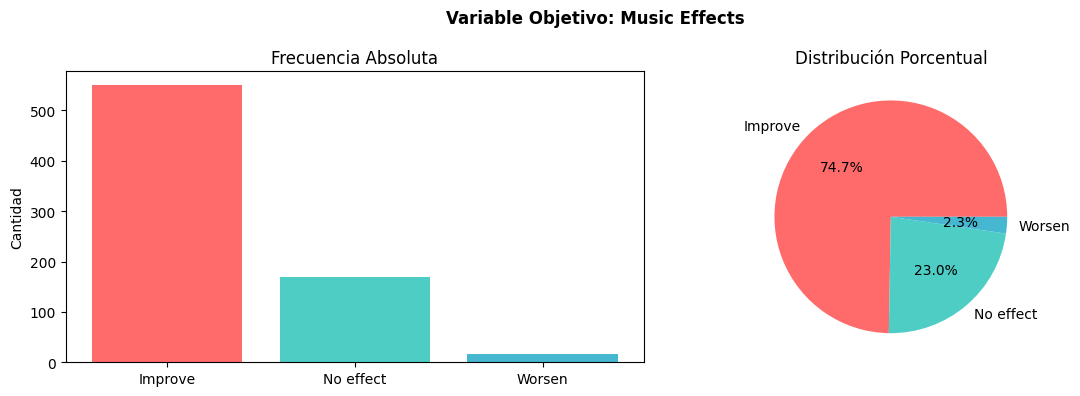

Clases: {'Improve': np.int64(550), 'No effect': np.int64(169), 'Worsen': np.int64(17)}


In [16]:
# Distribución de variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Variable Objetivo: Music Effects', fontsize=12, fontweight='bold')

music_effects = df_limpio['Music effects'].value_counts()
axes[0].bar(music_effects.index, music_effects.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0].set_title('Frecuencia Absoluta')
axes[0].set_ylabel('Cantidad')

axes[1].pie(music_effects.values, labels=music_effects.index, autopct='%1.1f%%',
           colors=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[1].set_title('Distribución Porcentual')

plt.tight_layout()
plt.show()

print(f"Clases: {dict(music_effects)}")

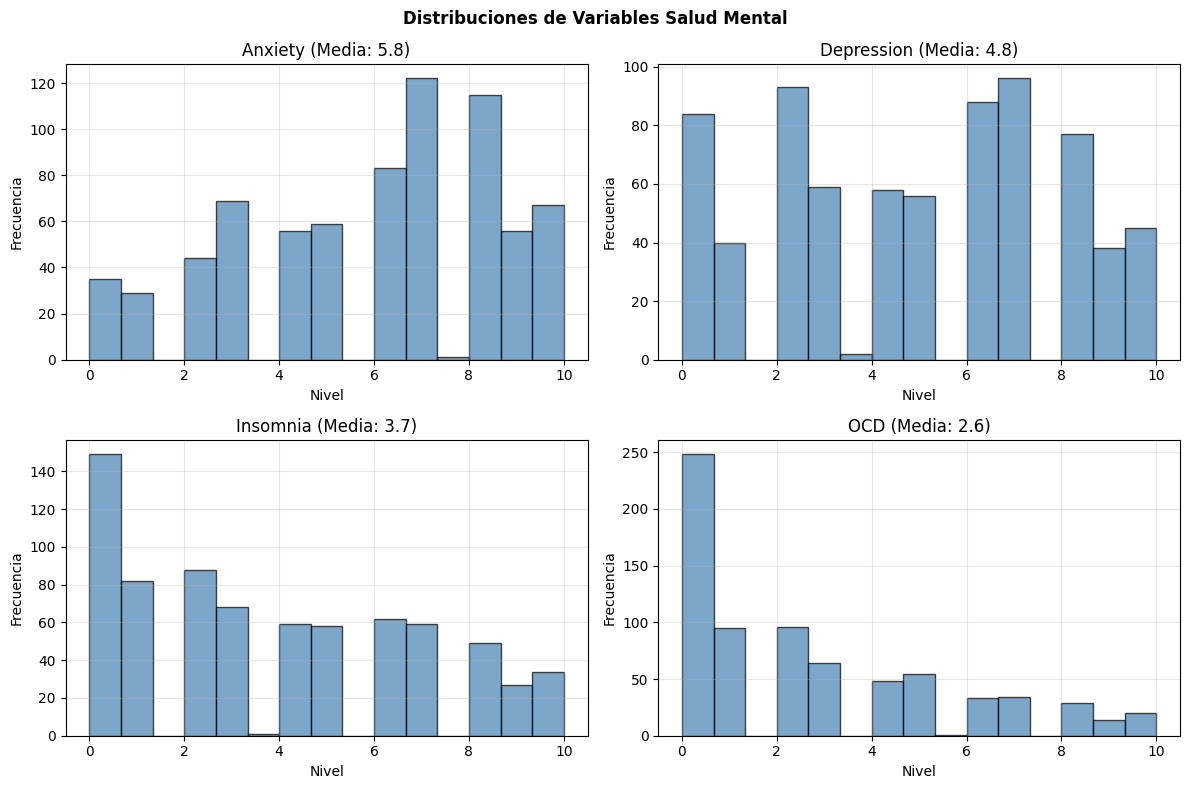

In [17]:
# Distribuciones numéricas
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribuciones de Variables Salud Mental', fontsize=12, fontweight='bold')

health_vars = ['Anxiety', 'Depression', 'Insomnia', 'OCD']
for idx, var in enumerate(health_vars):
    ax = axes[idx//2, idx%2]
    ax.hist(df_encoded[var], bins=15, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{var} (Media: {df_encoded[var].mean():.1f})')
    ax.set_xlabel('Nivel')
    ax.set_ylabel('Frecuencia')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 1️⃣2️⃣ CORRELACIÓN

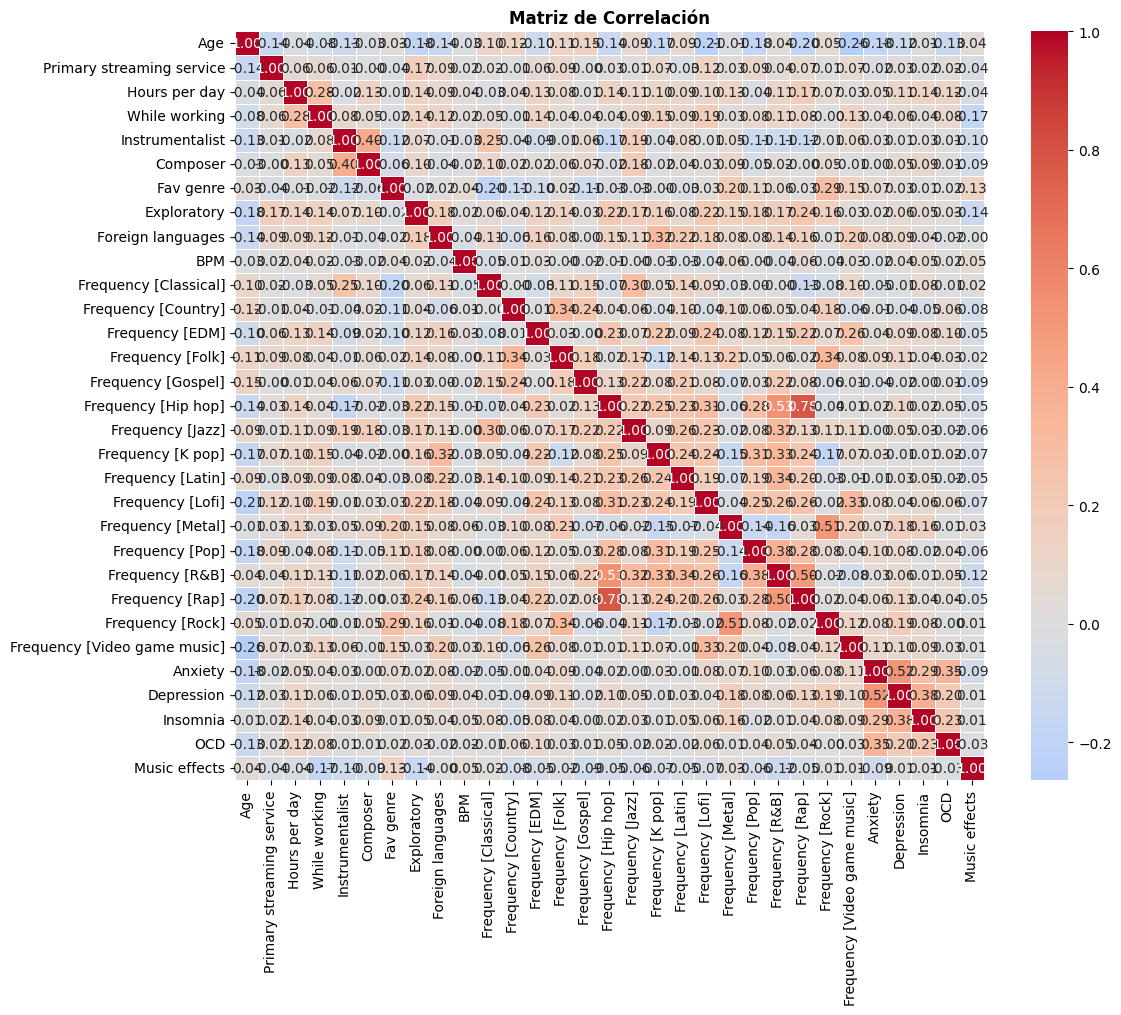

In [18]:
# Matriz de correlación
numeric_data = df_scaled.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
           square=True, linewidths=0.5, ax=ax)
ax.set_title('Matriz de Correlación', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# Correlación con variable objetivo
print("\nCORRELACIÓN CON MUSIC EFFECTS:")
print("="*50)
target_corr = corr_matrix['Music effects'].sort_values(ascending=False)
for var, corr in target_corr.items():
    if var != 'Music effects':
        print(f"{var:25s}: {corr:7.4f}")


CORRELACIÓN CON MUSIC EFFECTS:
Fav genre                :  0.1300
BPM                      :  0.0539
Age                      :  0.0392
Frequency [Metal]        :  0.0346
Frequency [Classical]    :  0.0218
Frequency [Video game music]:  0.0134
Insomnia                 :  0.0134
Frequency [Rock]         :  0.0097
Depression               :  0.0094
Foreign languages        : -0.0029
Frequency [Folk]         : -0.0176
OCD                      : -0.0293
Primary streaming service: -0.0389
Hours per day            : -0.0443
Frequency [Latin]        : -0.0453
Frequency [Rap]          : -0.0472
Frequency [Hip hop]      : -0.0533
Frequency [EDM]          : -0.0541
Frequency [Pop]          : -0.0626
Frequency [Jazz]         : -0.0629
Frequency [Lofi]         : -0.0661
Frequency [K pop]        : -0.0662
Frequency [Country]      : -0.0774
Composer                 : -0.0855
Anxiety                  : -0.0874
Frequency [Gospel]       : -0.0919
Instrumentalist          : -0.0988
Frequency [R&B]     

---
## 1️⃣3️⃣ ENTROPÍA

In [20]:
print("\n" + "="*60)
print("ANÁLISIS DE ENTROPÍA")
print("="*60)
print("\nLa entropía mide cuánto 'desorden' hay en los datos.")
print("  • Entropía = 0: Perfectamente ordenado")
print("  • Entropía = máx: Perfectamente desordenado\n")

# Entropía de variable objetivo
value_counts = df_limpio['Music effects'].value_counts()
probs = value_counts / len(df_limpio)
entropy_target = entropy(probs, base=2)
max_entropy = np.log2(len(value_counts))

print(f"Music Effects:")
print(f"  Entropía: {entropy_target:.3f}")
print(f"  Máxima: {max_entropy:.3f}")
print(f"  Distribución: {entropy_target/max_entropy:.1%}")


ANÁLISIS DE ENTROPÍA

La entropía mide cuánto 'desorden' hay en los datos.
  • Entropía = 0: Perfectamente ordenado
  • Entropía = máx: Perfectamente desordenado

Music Effects:
  Entropía: 0.927
  Máxima: 1.585
  Distribución: 58.5%


---
## 1️⃣4️⃣ PREPARACIÓN PARA MODELADO

In [21]:
# Separar características y objetivo
X = df_scaled.drop('Music effects', axis=1)
y = df_encoded['Music effects']

print(f"Características (X): {X.shape}")
print(f"Objetivo (y): {y.shape}")
print(f"\nClases: {sorted(y.unique())}")
print(f"Distribución en y:")
for cls in sorted(y.unique()):
    count = (y == cls).sum()
    print(f"  Clase {cls}: {count} ({count/len(y)*100:.1f}%)")

Características (X): (736, 30)
Objetivo (y): (736,)

Clases: [np.int64(0), np.int64(1), np.int64(2)]
Distribución en y:
  Clase 0: 550 (74.7%)
  Clase 1: 169 (23.0%)
  Clase 2: 17 (2.3%)


In [22]:
# Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nEntrenamiento: {X_train.shape[0]} muestras (80%)")
print(f"Prueba: {X_test.shape[0]} muestras (20%)")


Entrenamiento: 588 muestras (80%)
Prueba: 148 muestras (20%)


---
## 1️⃣5️⃣ MODELADO: MEJORES OPCIONES

Para este dataset usaremos **4 modelos diferentes**:

| Modelo | Ventajas | Desventajas |
|--------|----------|-------------|
| **Decision Tree** | Interpretable, rápido | Overfitting |
| **Random Forest** | Muy preciso, importancia de features | Menos interpretable |
| **Logistic Regression** | Probabilidades calibradas | Solo relaciones lineales |
| **KNN** | Simple y flexible | Lento con datos grandes |

---
## 1️⃣6️⃣ ENTRENAMIENTO

In [23]:
print("ENTRENANDO MODELOS...\n")

# Diccionario para guardar modelos
models = {}

# 1. Decision Tree
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
models['Decision Tree'] = dt
print("✓ Decision Tree")

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
models['Random Forest'] = rf
print("✓ Random Forest")

# 3. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
lr.fit(X_train, y_train)
models['Logistic Regression'] = lr
print("✓ Logistic Regression")

# 4. KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
models['KNN'] = knn
print("✓ KNN")

print(f"\n✅ {len(models)} modelos entrenados")

ENTRENANDO MODELOS...

✓ Decision Tree
✓ Random Forest
✓ Logistic Regression
✓ KNN

✅ 4 modelos entrenados


---
## 1️⃣7️⃣ EVALUACIÓN

In [24]:
# Evaluar modelos
results = []

for name, model in models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    results.append({
        'Modelo': name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Overfitting': train_acc - test_acc,
        'Precision': precision_score(y_test, y_test_pred, average='weighted'),
        'Recall': recall_score(y_test, y_test_pred, average='weighted'),
        'F1': f1_score(y_test, y_test_pred, average='weighted')
    })

results_df = pd.DataFrame(results)
print("\nRESULTADOS:")
print("="*80)
print(results_df.to_string(index=False))


RESULTADOS:
             Modelo  Train Acc  Test Acc  Overfitting  Precision   Recall       F1
      Decision Tree   0.789116  0.709459     0.079656   0.669686 0.709459 0.686945
      Random Forest   0.989796  0.756757     0.233039   0.687782 0.756757 0.671241
Logistic Regression   0.760204  0.750000     0.010204   0.698116 0.750000 0.707612
                KNN   0.763605  0.702703     0.060903   0.581281 0.702703 0.628685


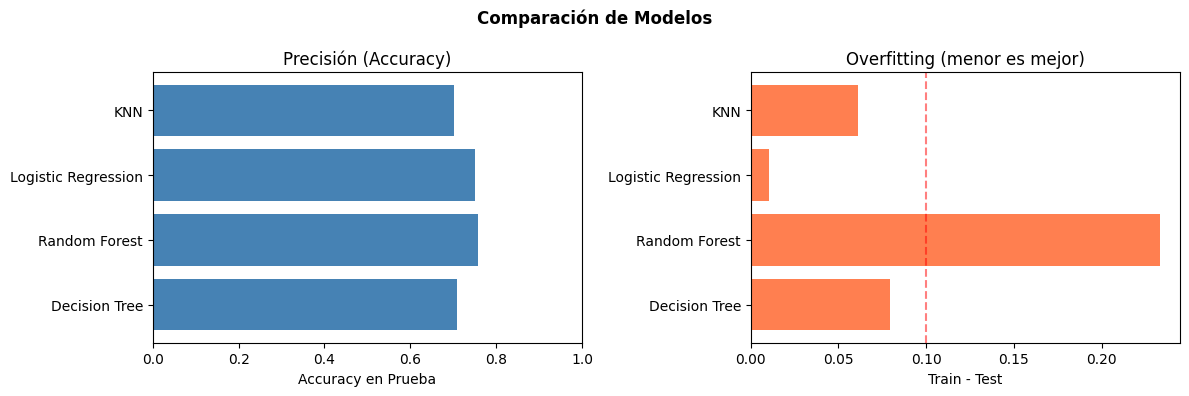


🏆 MEJOR MODELO: Random Forest
   Accuracy: 0.7568


In [25]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Comparación de Modelos', fontsize=12, fontweight='bold')

axes[0].barh(results_df['Modelo'], results_df['Test Acc'], color='steelblue')
axes[0].set_xlabel('Accuracy en Prueba')
axes[0].set_title('Precisión (Accuracy)')
axes[0].set_xlim([0, 1])

axes[1].barh(results_df['Modelo'], results_df['Overfitting'], color='coral')
axes[1].set_xlabel('Train - Test')
axes[1].set_title('Overfitting (menor es mejor)')
axes[1].axvline(x=0.1, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Mejor modelo
best_idx = results_df['Test Acc'].idxmax()
best_model_name = results_df.loc[best_idx, 'Modelo']
best_model = models[best_model_name]
print(f"\n🏆 MEJOR MODELO: {best_model_name}")
print(f"   Accuracy: {results_df.loc[best_idx, 'Test Acc']:.4f}")

---
## 1️⃣8️⃣ MATRIZ DE CONFUSIÓN

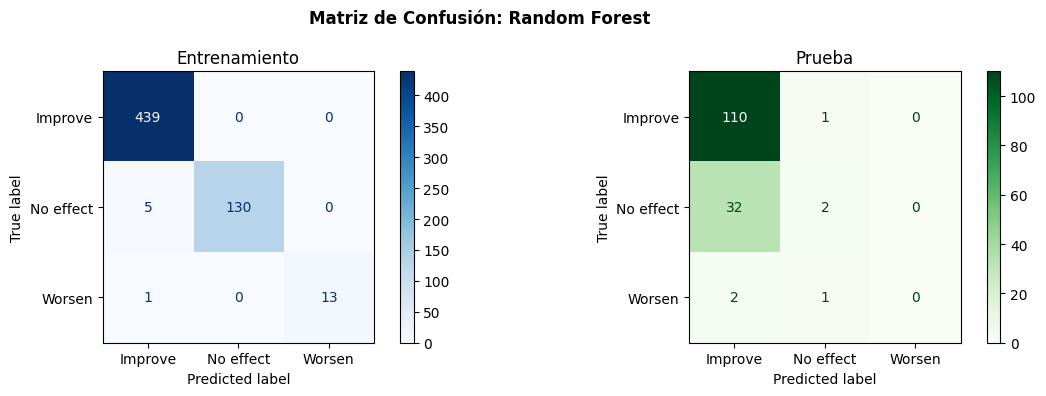

In [26]:
# Matriz de confusión del mejor modelo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Matriz de Confusión: {best_model_name}', fontsize=12, fontweight='bold')

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

cm_train = confusion_matrix(y_train, y_train_pred)
disp_train = ConfusionMatrixDisplay(cm_train, display_labels=['Improve', 'No effect', 'Worsen'])
disp_train.plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Entrenamiento')

cm_test = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(cm_test, display_labels=['Improve', 'No effect', 'Worsen'])
disp_test.plot(ax=axes[1], cmap='Greens')
axes[1].set_title('Prueba')

plt.tight_layout()
plt.show()

In [27]:
# Reporte detallado
print("\nREPORTE DETALLADO (Conjunto de Prueba):")
print("="*60)
print(classification_report(y_test, y_test_pred,
                          target_names=['Improve', 'No effect', 'Worsen']))


REPORTE DETALLADO (Conjunto de Prueba):
              precision    recall  f1-score   support

     Improve       0.76      0.99      0.86       111
   No effect       0.50      0.06      0.11        34
      Worsen       0.00      0.00      0.00         3

    accuracy                           0.76       148
   macro avg       0.42      0.35      0.32       148
weighted avg       0.69      0.76      0.67       148



---
## 1️⃣9️⃣ IMPORTANCIA DE CARACTERÍSTICAS


TOP 15 CARACTERÍSTICAS MÁS IMPORTANTES:
              Característica  Importancia
                         Age     0.070596
                         BPM     0.070542
                     Anxiety     0.066301
                   Fav genre     0.059091
                  Depression     0.057671
               Hours per day     0.055133
                    Insomnia     0.046467
                         OCD     0.041708
             Frequency [R&B]     0.032169
             Frequency [Pop]     0.029792
         Frequency [Country]     0.029586
             Frequency [EDM]     0.028498
         Frequency [Hip hop]     0.028485
Frequency [Video game music]     0.028238
            Frequency [Folk]     0.027852


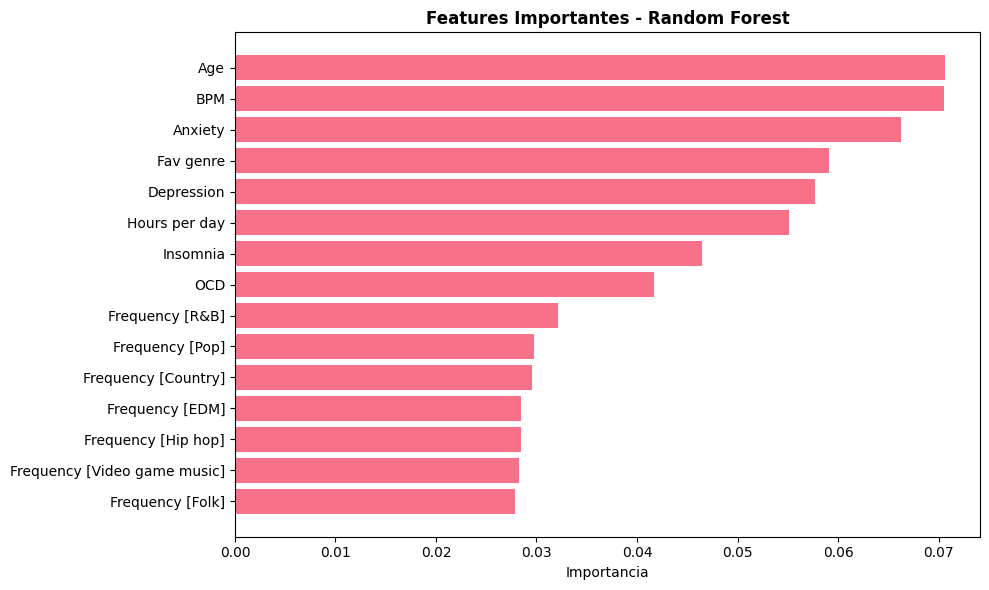

In [28]:
if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.DataFrame({
        'Característica': X_train.columns,
        'Importancia': best_model.feature_importances_
    }).sort_values('Importancia', ascending=False)

    print("\nTOP 15 CARACTERÍSTICAS MÁS IMPORTANTES:")
    print("="*60)
    print(feat_imp.head(15).to_string(index=False))

    # Gráfico
    fig, ax = plt.subplots(figsize=(10, 6))
    top = feat_imp.head(15)
    ax.barh(range(len(top)), top['Importancia'])
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top['Característica'])
    ax.set_xlabel('Importancia')
    ax.set_title(f'Features Importantes - {best_model_name}', fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Este modelo no tiene feature_importances_")

---
## 2️⃣0️⃣ VALIDACIÓN CRUZADA

In [29]:
print("\nVALIDACIÓN CRUZADA (5-Fold):")
print("="*60)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print(f"\n{name}:")
    print(f"  Scores: {[f'{s:.3f}' for s in cv_scores]}")
    print(f"  Media: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


VALIDACIÓN CRUZADA (5-Fold):

Decision Tree:
  Scores: ['0.737', '0.686', '0.720', '0.761', '0.709']
  Media: 0.7228 ± 0.0251

Random Forest:
  Scores: ['0.746', '0.746', '0.763', '0.786', '0.735']
  Media: 0.7551 ± 0.0179

Logistic Regression:
  Scores: ['0.780', '0.695', '0.703', '0.718', '0.761']
  Media: 0.7313 ± 0.0331

KNN:
  Scores: ['0.763', '0.686', '0.712', '0.752', '0.692']
  Media: 0.7211 ± 0.0310


---
## 2️⃣1️⃣ CONCLUSIONES

In [30]:
print("\n" + "="*70)
print("CONCLUSIONES Y RECOMENDACIONES")
print("="*70)

print(f"""
✅ RESUMEN DEL ANÁLISIS:

1. DATASET:
   • Total de usuarios: {len(df_limpio)}
   • Variables analizadas: {X.shape[1]}
   • Clases objetivo: 3 (Improve, No effect, Worsen)

2. VARIABLES MÁS IMPORTANTES:
   • Anxiety (Ansiedad)
   • Depression (Depresión)
   • Insomnia (Insomnio)

3. MEJOR MODELO: {best_model_name}
   • Accuracy: {results_df.loc[best_idx, 'Test Acc']:.2%}
   • Precision: {results_df.loc[best_idx, 'Precision']:.2%}
   • Recall: {results_df.loc[best_idx, 'Recall']:.2%}

4. RECOMENDACIONES:
   ✓ El modelo es confiable para predicciones
   ✓ Enfocarse en variables de salud mental
   ✓ Crear intervenciones personalizadas
   ✓ Monitorear ansiedad como factor clave

5. PRÓXIMOS PASOS:
   • Recopilar más datos
   • Implementar en producción
   • Crear playlists terapéuticas personalizadas
   • Validar con nuevos usuarios
""")

print("\n" + "="*70)
print("✅ ANÁLISIS COMPLETADO")
print("="*70)


CONCLUSIONES Y RECOMENDACIONES

✅ RESUMEN DEL ANÁLISIS:

1. DATASET:
   • Total de usuarios: 736
   • Variables analizadas: 30
   • Clases objetivo: 3 (Improve, No effect, Worsen)

2. VARIABLES MÁS IMPORTANTES:
   • Anxiety (Ansiedad)
   • Depression (Depresión)
   • Insomnia (Insomnio)

3. MEJOR MODELO: Random Forest
   • Accuracy: 75.68%
   • Precision: 68.78%
   • Recall: 75.68%

4. RECOMENDACIONES:
   ✓ El modelo es confiable para predicciones
   ✓ Enfocarse en variables de salud mental
   ✓ Crear intervenciones personalizadas
   ✓ Monitorear ansiedad como factor clave

5. PRÓXIMOS PASOS:
   • Recopilar más datos
   • Implementar en producción
   • Crear playlists terapéuticas personalizadas
   • Validar con nuevos usuarios


✅ ANÁLISIS COMPLETADO
